<a href="https://colab.research.google.com/github/Ravi-attada/Algorithms-and-Analysis/blob/main/Algorithms_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

minflow max cut

In [10]:
from collections import deque, defaultdict

class Graph:
    def __init__(self, vertices):
        self.V = vertices
        self.graph = defaultdict(lambda: defaultdict(int))

    def add_edge(self, u, v, capacity):
        self.graph[u][v] = capacity

    def bfs(self, s, t, parent):
        visited = [False] * self.V
        queue = deque([s])
        visited[s] = True

        while queue:
            u = queue.popleft()

            for v, cap in self.graph[u].items():
                if not visited[v] and cap > 0:
                    queue.append(v)
                    visited[v] = True
                    parent[v] = u
                    if v == t:
                        return True
        return False

    def edmonds_karp(self, source, sink):
        parent = [-1] * self.V
        max_flow = 0

        while self.bfs(source, sink, parent):
            path_flow = float("inf")
            v = sink
            while v != source:
                u = parent[v]
                path_flow = min(path_flow, self.graph[u][v])
                v = u

            max_flow += path_flow

            # update residual capacities
            v = sink
            while v != source:
                u = parent[v]
                self.graph[u][v] -= path_flow
                self.graph[v][u] += path_flow
                v = u

        return max_flow

    # Find the minimum cut edges
    def min_cut(self, source):
        visited = [False] * self.V
        queue = deque([source])
        visited[source] = True

        while queue:
            u = queue.popleft()
            for v, cap in self.graph[u].items():
                if cap > 0 and not visited[v]:
                    visited[v] = True
                    queue.append(v)

        cut_edges = []
        for u in range(self.V):
            if visited[u]:
                for v, cap in self.graph[u].items():
                    if cap == 0 and not visited[v]:  # saturated edge
                        cut_edges.append((u, v))

        return cut_edges


g = Graph(6)
g.add_edge(0, 1, 16)
g.add_edge(0, 2, 13)
g.add_edge(1, 2, 10)
g.add_edge(1, 3, 12)
g.add_edge(2, 1, 4)
g.add_edge(2, 4, 14)
g.add_edge(3, 2, 9)
g.add_edge(3, 5, 20)
g.add_edge(4, 3, 7)
g.add_edge(4, 5, 4)

source = 0
sink = 5

maxflow = g.edmonds_karp(source, sink)
print("Maximum Flow:", maxflow)

cut_edges = g.min_cut(source)
print("Min-Cut Edges:", cut_edges)


Maximum Flow: 23
Min-Cut Edges: [(1, 3), (4, 3), (4, 5)]


CVXPY Solution : [0.000000, 4.000000]
Objective value : 8.000000


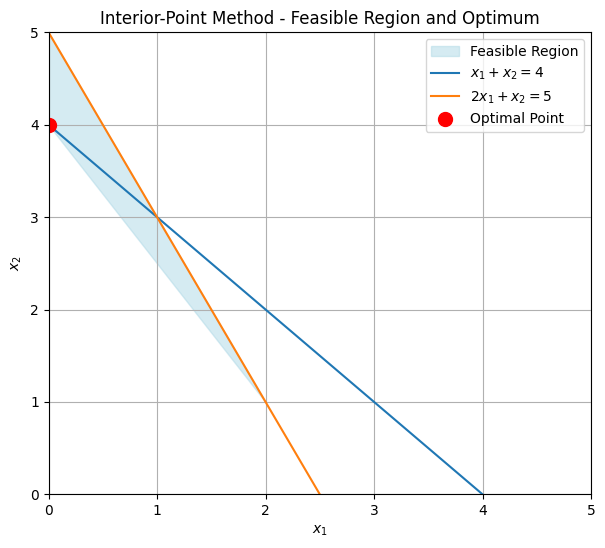

In [1]:

import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

# Variables
x1 = cp.Variable()
x2 = cp.Variable()

# Objective
objective = cp.Minimize(3 * x1 + 2 * x2)

# Constraints
constraints = [
    x1 + x2 >= 4,
    2 * x1 + x2 <= 5,
    x1 >= 0,
    x2 >= 0
]

prob = cp.Problem(objective, constraints)
prob.solve()

sol = np.array([x1.value, x2.value], dtype=float)
z_opt = 3 * sol[0] + 2 * sol[1]

print("CVXPY Solution : [{:.6f}, {:.6f}]".format(sol[0], sol[1]))
print("Objective value : {:.6f}".format(z_opt))

xx = np.linspace(0, 5, 400)
c1 = 4 - xx         # x1 + x2 = 4
c2 = 5 - 2 * xx     # 2x1 + x2 = 5

plt.figure(figsize=(7, 6))

x_fill = [0, 0, 1, 2]      # Correct polygon points
y_fill = [4, 5, 3, 1]

plt.fill(x_fill, y_fill, color='lightblue', alpha=0.5, label='Feasible Region')

plt.plot(xx, c1, label=r'$x_1 + x_2 = 4$')
plt.plot(xx, c2, label=r'$2x_1 + x_2 = 5$')


plt.plot(sol[0], sol[1], 'ro', markersize=10, label='Optimal Point')

plt.xlim(0, 5)
plt.ylim(0, 5)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Interior-Point Method - Feasible Region and Optimum')
plt.legend()
plt.grid(True)
plt.show()


INTEROR POINT METHOD

In [14]:
def min_cut(graph):
    g = {u: dict(v) for u, v in graph.items()}   # copy
    nodes = list(g)
    INF = 10**18
    ans = INF

    while len(nodes) > 1:
        used = set()
        w = {nodes[0]: 0}
        prev = None

        for _ in range(len(nodes)):
            # pick max weighted unused node
            cur = max((x for x in w if x not in used), key=w.get)
            used.add(cur)

            # last node → update answer and merge
            if len(used) == len(nodes):
                ans = min(ans, w[cur])          # possible mincut

                # merge prev + cur
                for nb, wt in g[cur].items():
                    if nb != prev:
                        g[prev][nb] = g[prev].get(nb,0) + wt
                        g[nb][prev] = g[nb].get(prev,0) + wt

                # remove merged node
                nodes.remove(cur)
                for x in nodes: g[x].pop(cur, None)
                g.pop(cur, None)
                break

            prev = cur
            # update weights
            for nb, wt in g[cur].items():
                if nb not in used:
                    w[nb] = w.get(nb,0) + wt

    return ans

    graph = {
 'A': {'B':3,'C':2},
 'B': {'A':3,'C':4,'D':2},
 'C': {'A':2,'B':4,'D':1},
 'D': {'B':2,'C':1}
}

print("Minimum Cut =", min_cut(graph))



Minimum Cut = 4
